# Chapter 12 | 강화 학습 — DQN으로 CartPole 풀기


## 🔑 핵심 개념 요약

### Q-러닝과 DQN의 차이
- **Q-러닝**: 상태-행동 쌍마다 Q값을 테이블에 저장 → 상태 공간이 크면 불가능  
- **DQN**: Q함수를 **합성곱 신경망**으로 근사 → 이미지처럼 고차원 입력 처리 가능

### DQN의 두 가지 핵심 트릭
| 기법 | 설명 | 목적 |
|------|------|------|
| **리플레이 메모리** | 경험 $(s, a, r, s')$을 버퍼에 저장 후 랜덤 샘플링 | 데이터 간 상관관계 제거 |
| **타깃 네트워크** | Q-네트워크를 주기적으로 복사한 별도 네트워크로 목표값 계산 | 학습 안정성 향상 |

### 손실 함수
$$L(\theta) = \mathbb{E}_{(s,a,r,s')}\left[\left(r + \gamma \max_{a'} Q(s', a'; \theta^{-}) - Q(s, a; \theta)\right)^2\right]$$

- $\theta$: policy_net의 파라미터  
- $\theta^{-}$: target_net의 파라미터 (고정됨)  
- $\gamma$: 할인율 (미래 보상의 현재 가치)


## 코드 12-1 | 라이브러리 호출

DQN 구현에 필요한 라이브러리를 모두 불러옵니다.  
- `gym`: OpenAI의 강화학습 환경 라이브러리  
- `PIL.Image`: 환경에서 캡처한 화면을 이미지로 처리  
- `torchvision.transforms`: 이미지를 텐서로 변환하는 파이프라인  
- `collections.namedtuple`: 경험 튜플 `(state, action, next_state, reward)`을 구조화

In [18]:
import gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple       # namedtuple: 경험 저장용
from itertools import count              # count: 무한 루프용 (0, 1, 2, ... 무한 생성)
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T

env = gym.make('CartPole-v1', render_mode='rgb_array').unwrapped
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## 코드 12-2 | 한글 깨짐 방지

matplotlib 기본 설정은 한글 폰트를 지원하지 않아 글자가 깨집니다.  
Windows 기준으로 맑은 고딕 폰트(`malgun.ttf`)를 직접 지정해 줍니다.  


In [29]:
import subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔폰트 설치
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

# 폰트 파일 직접 지정해서 등록
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 확인
print(plt.rcParams['font.family'])

['NanumGothic']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'

## 코드 12-3 | 리플레이 메모리 (Experience Replay)

일반적인 온라인 학습에서는 에이전트가 경험하는 데이터가 **시간적으로 연속**되어 있어  
데이터 간 **상관관계(correlation)**가 높습니다. 이렇게 되면 신경망이 편향된 방향으로 학습됩니다.

리플레이 메모리는 다음을 해결합니다:
1. 과거 경험을 버퍼에 저장
2. 학습 시 **무작위 샘플링** → 데이터 간 상관관계 제거
3. 하나의 경험을 여러 번 재사용 → 데이터 효율성 향상

### Transition namedtuple
경험의 한 단위: $(s_t, a_t, r_t, s_{t+1})$ — 현재 상태, 행동, 보상, 다음 상태

In [20]:
# 경험(transition)을 담을 namedtuple 정의: (상태, 행동, 다음상태, 보상)
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))  # ①

class ReplayMemory(object):
    """고정 크기의 원형 버퍼(circular buffer)로 경험을 저장하는 리플레이 메모리"""

    def __init__(self, capacity):          # capacity: 최대 저장 가능한 경험 수
        self.capacity = capacity
        self.memory = []                   # 경험을 저장할 리스트
        self.position = 0                  # 현재 쓰기 위치 (원형 버퍼 포인터)

    def push(self, *args):                 # ② 새 경험을 메모리에 추가
        if len(self.memory) < self.capacity:
            self.memory.append(None)       # 용량이 남아 있으면 새 슬롯 추가
        self.memory[self.position] = Transition(*args)          # 경험 저장
        self.position = (self.position + 1) % self.capacity     # 원형 인덱스 갱신

    def sample(self, batch_size):          # 학습에 사용할 배치를 무작위로 샘플링
        return random.sample(self.memory, batch_size)

    def __len__(self):                     # 현재 저장된 경험의 수 반환
        return len(self.memory)

## 코드 12-4 | DQN 모델 네트워크

### 네트워크 구조
CartPole 화면 이미지(RGB)를 입력으로 받아 각 행동(왼쪽/오른쪽)의 Q값을 출력합니다.

```
입력 (3×H×W 이미지)
    ↓ Conv2d(3→16, k=5, s=2) + BN + ReLU
    ↓ Conv2d(16→32, k=5, s=2) + BN + ReLU  
    ↓ Conv2d(32→32, k=5, s=2) + BN + ReLU
    ↓ Flatten
    ↓ Linear(convw×convh×32 → n_actions)
출력 (Q값: 행동 수만큼)
```

### `conv2d_size_out` 함수
Conv2d 통과 후 출력 크기를 계산하는 내부 함수:  
$$\text{output\_size} = \left\lfloor \frac{\text{size} - (\text{kernel\_size} - 1) - 1}{\text{stride}} \right\rfloor + 1$$

이 함수를 3번 중첩 적용해 Linear 레이어의 입력 크기를 자동 계산합니다.

In [21]:
class DQN(nn.Module):
    """화면 이미지를 입력받아 행동별 Q값을 출력하는 합성곱 신경망"""

    def __init__(self, h, w, outputs):     # h, w: 입력 이미지 높이/너비, outputs: 행동 수
        super(DQN, self).__init__()

        # 3개의 Conv-BN 블록 정의
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2)   # RGB(3채널) → 16채널
        self.bn1   = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.bn2   = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
        self.bn3   = nn.BatchNorm2d(32)

        # Conv2d 통과 후 출력 크기를 계산하는 함수 (Linear 입력 크기 자동 계산용)
        def conv2d_size_out(size, kernel_size=5, stride=2):
            return (size - (kernel_size - 1) - 1) // stride + 1  # ①

        # 너비(w)와 높이(h) 각각 3번 conv 통과 후 크기 계산
        convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(w)))
        convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(h)))

        # Flatten 후 Linear 레이어 입력 크기 = convw × convh × 32채널
        linear_input_size = convw * convh * 32
        self.head = nn.Linear(linear_input_size, outputs)         # Q값 출력층

    def forward(self, x):
        """순전파: Conv-BN-ReLU 블록 3개 → Flatten → Linear"""
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        # x.size(0): 배치 크기, -1: 나머지 차원을 1D로 펼침
        return self.head(x.view(x.size(0), -1))

## 코드 12-5 | 이미지 추출 및 처리

DQN의 입력은 CartPole **화면 이미지**입니다. 원시 화면 전체를 그대로 쓰면 불필요한 정보가 많으므로,  
**카트 주변 영역만** 잘라서 사용합니다.

### 처리 파이프라인
```
env.render()       → RGB 배열 (H × W × 3)
transpose          → (3 × H × W) 텐서 형태로
세로 크롭          → 화면 40%~80% 구간 (카트가 있는 높이)
가로 크롭          → 카트 중심 기준 view_width 만큼 (좌우 잘림)
정규화             → 픽셀값 / 255 → [0, 1]
resize(T.Resize)   → 40×N 픽셀로 축소
```

### 상태 표현
단일 프레임이 아닌 **이전 프레임과의 차이** (`current_screen - last_screen`)를  
상태로 사용해 **움직임(속도) 정보**를 암묵적으로 인코딩합니다.

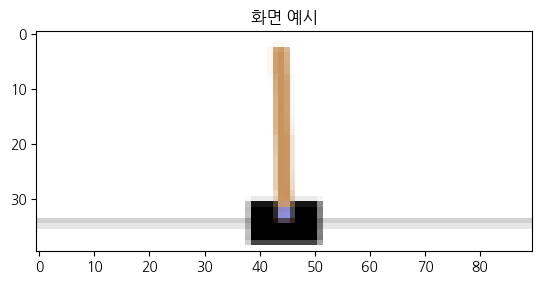

In [31]:
import pyglet

resize = T.Compose([
    T.ToPILImage(),
    T.Resize(40, interpolation=Image.BICUBIC),
    T.ToTensor()
])

def get_cart_location(screen_width):
    world_width = env.x_threshold * 2
    scale = screen_width / world_width
    return int(env.state[0] * scale + screen_width / 2.0)

def get_screen():
    rendered = env.render()

    # 빈 리스트이거나 None이면 한 번 더 시도
    if not isinstance(rendered, np.ndarray):
        env.render()
        rendered = env.render()
    if isinstance(rendered, list):
        if len(rendered) == 0:
            # 빈 경우 step을 하나 밟아서 강제로 렌더링
            env.step(0)
            rendered = env.render()
        rendered = rendered[0] if isinstance(rendered, list) else rendered

    screen = np.array(rendered).transpose((2, 0, 1))
    _, screen_height, screen_width = screen.shape
    screen = screen[:, int(screen_height * 0.4):int(screen_height * 0.8)]
    view_width = int(screen_width * 0.6)
    cart_location = get_cart_location(screen_width)

    if cart_location < view_width // 2:
        slice_range = slice(view_width)
    elif cart_location > (screen_width - view_width // 2):
        slice_range = slice(screen_width - view_width, None)
    else:
        slice_range = slice(cart_location - view_width // 2,
                            cart_location + view_width // 2)

    screen = screen[:, :, slice_range]
    screen = np.ascontiguousarray(screen, dtype=np.float32) / 255
    screen = torch.from_numpy(screen)
    screen = resize(screen).unsqueeze(0).to(device)
    return screen

# 시각화할 때만 4D → HWC numpy로 변환
env.reset()
plt.figure()
plt.imshow(get_screen().squeeze(0).permute(1, 2, 0).cpu().numpy(), interpolation='none')
plt.title('화면 예시')
plt.show()

## 코드 12-6 | 모델 객체화 및 하이퍼파라미터 정의

### 주요 하이퍼파라미터 설명
| 파라미터 | 값 | 설명 |
|----------|-----|------|
| `BATCH_SIZE` | 128 | 리플레이 메모리에서 한 번에 샘플링하는 경험 수 |
| `GAMMA` | 0.999 | 할인율 — 미래 보상을 현재 가치로 환산하는 비율 |
| `EPS_START` | 0.9 | ε-greedy 탐험 확률 초기값 |
| `EPS_END` | 0.05 | ε 최솟값 (탐험을 완전히 멈추지 않음) |
| `EPS_DECAY` | 200 | ε 감소 속도 (클수록 느리게 감소) |
| `TARGET_UPDATE` | 10 | target_net 파라미터를 policy_net에서 복사하는 주기(에피소드) |

### ε-greedy 정책 (엡실론-그리디)
$$\varepsilon = \varepsilon_{\text{end}} + (\varepsilon_{\text{start}} - \varepsilon_{\text{end}}) \cdot e^{-\text{steps\_done} / \varepsilon_{\text{decay}}}$$

- 학습 초반: ε ≈ 0.9 → **탐험(exploration)** 위주 (무작위 행동)
- 학습 후반: ε ≈ 0.05 → **활용(exploitation)** 위주 (greedy 행동)

### policy_net vs target_net
- `policy_net`: 매 스텝 학습되는 메인 Q-네트워크
- `target_net`: `TARGET_UPDATE` 에피소드마다 policy_net을 복사받아 목표값 계산에만 사용  
  → 목표값이 급격히 변하지 않아 학습이 안정적

In [33]:
# ── 환경 초기화 및 화면 크기 파악 ────────────────────────────
env.reset()
env.render()  # 첫 렌더 워밍업 호출
init_screen = get_screen()
_, screen_height, screen_width = init_screen.squeeze(0).shape

n_actions = env.action_space.n

# ── 하이퍼파라미터 설정 ──────────────────────────────────────
BATCH_SIZE   = 128    # 리플레이 메모리에서 샘플링할 배치 크기
GAMMA        = 0.999  # 할인율 (감마): 미래 보상의 현재 가치 비율
EPS_START    = 0.9    # ε-greedy 탐험 확률 초기값
EPS_END      = 0.05   # ε-greedy 탐험 확률 최솟값
EPS_DECAY    = 200    # ε 감소 속도 (지수 감쇠)
TARGET_UPDATE = 10    # target_net을 policy_net으로 동기화하는 에피소드 주기

# ── 환경 초기화 및 화면 크기 파악 ────────────────────────────
init_screen = get_screen()  # ① gym 화면 크기를 올바르게 초기화하기 위해 get_screen() 호출
_, screen_height, screen_width = init_screen.squeeze(0).shape

# 행동 수 (CartPole: 왼쪽=0, 오른쪽=1)
n_actions = env.action_space.n

# ── policy_net / target_net 생성 ─────────────────────────────
policy_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net = DQN(screen_height, screen_width, n_actions).to(device)

# target_net을 policy_net과 동일하게 초기화 ②
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()  # target_net은 추론 전용 (가중치 업데이트 X)

# ── 옵티마이저 & 리플레이 메모리 ─────────────────────────────
optimizer = optim.RMSprop(policy_net.parameters())  # RMSprop 사용 (RL에서 자주 사용)
memory    = ReplayMemory(10000)                     # 최대 10,000개 경험 저장

steps_done = 0  # 전체 스텝 수 (ε 감소에 사용)

# ── ε-greedy 행동 선택 함수 ───────────────────────────────────
def select_action(state):
    """현재 상태에서 ε-greedy 정책으로 행동을 선택"""
    global steps_done
    sample = random.random()

    # 지수 감쇠로 ε 계산: 초반엔 탐험, 후반엔 활용 위주
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1

    if sample > eps_threshold:
        # 활용(exploitation): Q값이 가장 큰 행동 선택 ③
        with torch.no_grad():
            # max(1)[1]: 각 샘플에서 Q값 최댓값의 인덱스 → view(1,1): (1,1) 형태로
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        # 탐험(exploration): 무작위 행동 선택
        return torch.tensor([[random.randrange(n_actions)]],
                             device=device, dtype=torch.long)

episode_durations = []  # 각 에피소드 지속 시간 기록

## 코드 12-7 | 모델 최적화 함수 (optimize_model)

### 학습 한 스텝의 전체 흐름

```
1. 리플레이 메모리에서 BATCH_SIZE개 샘플링
2. 배치를 (state, action, reward, next_state)로 분리
3. Q(s, a) 계산  ← policy_net 사용
4. V(s') = max_a' Q(s', a') 계산  ← target_net 사용 (종료 상태는 0)
5. 목표값 = reward + γ × V(s')
6. Smooth L1 Loss(Huber Loss) 계산
7. 역전파 & 파라미터 업데이트 (기울기 클리핑 포함)
```

### Smooth L1 Loss (Huber Loss)
$$L(x, y) = \begin{cases} 0.5(x-y)^2 / \beta & |x-y| < \beta \\ |x-y| - 0.5\beta & \text{otherwise} \end{cases}$$

- 오차가 작을 때: L2처럼 매끄럽게 → 수렴 안정적  
- 오차가 클 때: L1처럼 선형 → **기울기 폭발(gradient explosion) 방지**  

### 기울기 클리핑 (`clamp_(-1, 1)`)
각 파라미터의 기울기를 [-1, 1] 범위로 강제 제한 → 추가적인 안정성 확보

In [34]:
def optimize_model():
    """리플레이 메모리에서 배치 샘플링 후 DQN 파라미터 한 스텝 업데이트"""
    if len(memory) < BATCH_SIZE:  # 메모리에 배치 크기 미만이면 학습 생략
        return

    # ── 1. 배치 샘플링 및 분리 ────────────────────────────────
    transitions = memory.sample(BATCH_SIZE)
    # zip(*transitions): [(s1,a1,...), (s2,a2,...)] → (s1,s2,...), (a1,a2,...) 형태로 전치
    batch = Transition(*zip(*transitions))  # ①

    # 종료 상태가 아닌 next_state에 대한 불리언 마스크 생성 ②
    non_final_mask = torch.tensor(
        tuple(map(lambda s: s is not None, batch.next_state)),
        device=device, dtype=torch.bool
    )
    # 종료되지 않은 next_state만 모아서 하나의 텐서로 결합
    non_final_next_states = torch.cat(
        [s for s in batch.next_state if s is not None]
    )

    state_batch  = torch.cat(batch.state)   # 현재 상태 배치
    action_batch = torch.cat(batch.action)  # 행동 배치
    reward_batch = torch.cat(batch.reward)  # 보상 배치

    # ── 2. Q(s, a) 계산 (policy_net) ────────────────────────
    # gather(1, action_batch): 실제로 선택한 행동의 Q값만 추출 ③
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # ── 3. V(s') = max_a' Q(s', a') 계산 (target_net) ────────
    next_state_values = torch.zeros(BATCH_SIZE, device=device)  # 종료 상태는 0으로 초기화
    next_state_values[non_final_mask] = (
        target_net(non_final_next_states).max(1)[0].detach()    # detach: 기울기 계산 제외
    )

    # ── 4. 목표 Q값 (Bellman 방정식) ─────────────────────────
    # expected = reward + γ × V(s_{t+1}) ④
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # ── 5. Smooth L1 Loss (Huber Loss) 계산 ─────────────────
    loss = F.smooth_l1_loss(
        state_action_values,
        expected_state_action_values.unsqueeze(1)  # 차원 맞추기: (B,) → (B,1)
    )

    # ── 6. 역전파 및 파라미터 업데이트 ─────────────────────────
    optimizer.zero_grad()    # 기존 기울기 초기화
    loss.backward()          # 역전파
    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)  # 기울기 클리핑: [-1, 1] 범위로 제한
    optimizer.step()         # 파라미터 업데이트

## 코드 12-8 | 모델 학습 (메인 학습 루프)

### 전체 학습 과정 (에피소드 단위)

```
for 에피소드 in range(num_episodes):
    환경 초기화
    state = current_screen - last_screen  ← 화면 차이로 움직임 인코딩
    
    for 스텝 t in count():  ← 에피소드가 끝날 때까지 반복
        ① 행동 선택 (ε-greedy)
        ② env.step(action) → reward, done, next_state
        ③ 경험을 리플레이 메모리에 저장
        ④ optimize_model() → policy_net 파라미터 업데이트
        ⑤ done이면 에피소드 종료
    
    TARGET_UPDATE마다 target_net ← policy_net 파라미터 복사
```

### 상태 표현: 화면 차이
`state = current_screen - last_screen`
- 단순 픽셀값이 아니라 **프레임 간 변화량** → 막대의 속도/방향 정보 포함
- CartPole은 위치뿐 아니라 **속도**도 중요하므로 이 방법이 효과적


In [41]:
num_episodes = 300

for i_episode in range(num_episodes):

    # ── 에피소드 초기화 ────────────────────────────────────────
    env.reset()                                    # 환경과 상태 초기화
    last_screen    = get_screen()                  # 이전 화면 캡처
    current_screen = get_screen()                  # 현재 화면 캡처
    state = current_screen - last_screen           # 화면 차이 = 상태 (움직임 정보 내포)

    for t in count():  # 에피소드가 끝날 때까지 무한 반복

        # ── ① 행동 선택 및 환경 스텝 실행 ────────────────────
        action = select_action(state)              # ε-greedy 정책으로 행동 선택
        _, reward, terminated, truncated, _ = env.step(action.item())  # 환경에 행동 적용
        done = terminated or truncated             # 둘 중 하나라도 True면 에피소드 종료
        reward = torch.tensor([reward], device=device)  # 보상을 텐서로 변환

        # ── ② 다음 상태 관찰 ─────────────────────────────────
        last_screen = current_screen
        if not done:                               # 게임이 계속되면
            current_screen = get_screen()          # 새로운 화면 캡처 (done이면 호출 안 함 → 워닝 방지)
            next_state = current_screen - last_screen  # 화면 차이가 다음 상태
        else:                                      # 게임이 종료되면
            next_state = None                      # 종료 상태는 None으로 표시

        # ── ③ 경험을 리플레이 메모리에 저장 ──────────────────
        memory.push(state, action, next_state, reward)  # (s, a, s', r) 저장

        state = next_state                         # 다음 상태로 전이

        # ── ④ policy_net 최적화 한 스텝 실행 ─────────────────
        optimize_model()

        if done:                                   # 에피소드 종료 시
            episode_durations.append(t + 1)        # 지속 시간 기록 (t+1: 1부터 시작)
            break                                  # 내부 루프 탈출 → env.reset()으로 돌아감

    # ── ⑤ target_net 주기적 업데이트 ─────────────────────────
    if i_episode % TARGET_UPDATE == 0:             # TARGET_UPDATE 에피소드마다
        target_net.load_state_dict(policy_net.state_dict())  # policy_net 가중치를 target_net에 복사

print('완료')
env.close()   # 환경 종료
plt.show()    # 최종 그래프 출력

완료


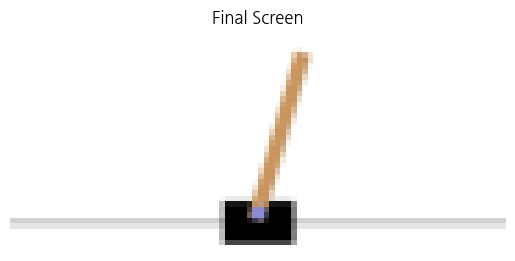

In [43]:
final_screen = get_screen().cpu().squeeze(0).permute(1, 2, 0).numpy()
plt.figure()
plt.imshow(final_screen, interpolation='none')
plt.title('Final Screen')
plt.axis('off')
plt.show()
env.close()

---

## 학습 결과 시각화

에피소드 지속 시간(`episode_durations`)을 그래프로 확인합니다.  
학습이 잘 될수록 막대가 더 오래 버티므로 지속 시간이 길어집니다.

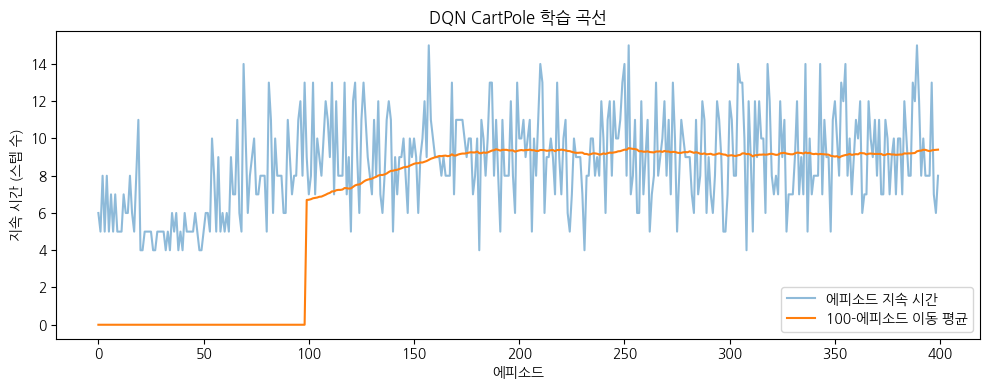

In [42]:
# 학습 곡선 시각화
plt.figure(figsize=(10, 4))
durations = torch.tensor(episode_durations, dtype=torch.float)
plt.plot(durations.numpy(), alpha=0.5, label='에피소드 지속 시간')

# 이동 평균 (100 에피소드 이상일 경우)
if len(durations) >= 100:
    means = durations.unfold(0, 100, 1).mean(1).view(-1)
    means = torch.cat((torch.zeros(99), means))
    plt.plot(means.numpy(), label='100-에피소드 이동 평균')

plt.xlabel('에피소드')
plt.ylabel('지속 시간 (스텝 수)')
plt.title('DQN CartPole 학습 곡선')
plt.legend()
plt.tight_layout()
plt.show()

## 그래프 해석

- 에피소드 지속 시간(파란 선)은 전체 구간에서 4~14 스텝 사이를 불규칙하게 변동하며, 뚜렷한 상승 추세를 보이지 않는다.
- 100-에피소드 이동 평균(주황 선)은 에피소드 100 이후부터 산출되기 시작하여 약 8~10 스텝 수준에서 수평을 유지한다.
- 400 에피소드에 걸쳐 이동 평균이 거의 상승하지 않고 평탄한 구간에 머무르고 있어, 현재 설정 하에서는 학습이 수렴에 가까워진 상태로 판단된다.
- CartPole-v1의 성공 기준인 에피소드당 200 스텝과 비교하면, 현재 평균 성능(약 9 스텝)은 목표치의 약 4.5% 수준에 그친다.


## 성능이 낮은 원인 분석

현재 낮은 성능의 주요 원인은 다음과 같이 분석된다. 첫째, 수치 상태값 대신 **화면 이미지를 입력**으로 사용하여 학습해야 할 표현 공간이 넓다. 둘째, 이미지 기반 DQN의 특성상 **400 에피소드는 수렴에 충분하지 않으며**, 수천 회 이상이 필요하다. 셋째, 학습 초반 리플레이 메모리가 충분히 채워지지 않은 상태에서의 업데이트는 **편향된 가중치 갱신**을 유발할 수 있다. 본 교재 예제는 성능 달성보다 **DQN 구조 이해**를 목적으로 설계되었으므로, 하이퍼파라미터 최적화가 이루어지지 않은 점도 한계로 작용한다. 개선을 위해서는 `num_episodes`를 1,000 이상으로 늘리거나, 이미지 대신 위치·속도·각도·각속도의 **수치 상태값 4개를 직접 입력**으로 전환하는 방식이 가장 효과적이다.


---

## 💡 핵심 정리

| 구성 요소 | 역할 |
|-----------|------|
| `ReplayMemory` | 경험 $(s, a, r, s')$ 저장 및 랜덤 샘플링 → 상관관계 제거 |
| `DQN (policy_net)` | 메인 Q-네트워크: 매 스텝 업데이트 |
| `DQN (target_net)` | 목표값 계산용: `TARGET_UPDATE` 주기마다 복사 |
| `select_action` | ε-greedy: 초반 탐험 → 후반 활용 |
| `optimize_model` | Bellman 방정식 + Huber Loss + 기울기 클리핑 |
| 상태 표현 | 화면 차이 (`current - last`) → 속도 정보 내포 |